# 알약 데이터셋 EDA

이 노트북은 `dataset.py`/`utils.py`에 대한 의존성 없이 독립적으로 실행할 수 있도록,
필요한 `PillDataset` 클래스와 EDA 함수들을 모두 이 파일 안에 포함했습니다.

실행 위치: `notebooks/` 폴더 (데이터 경로가 `../data/raw` 기준 상대경로입니다).

In [28]:
import os
import json
import random
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

## Dataset 클래스 (dataset.py에서 가져온 독립 버전)

In [56]:
import os
import json
from PIL import Image
import torch
from torch.utils.data import Dataset

class PillDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform
        
        # 1. 이미지 경로 수집
        self.img_paths = []
        for root, _, files in os.walk(self.img_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.img_paths.append(os.path.join(root, f))

        # 2. 어노테이션 JSON 경로 리스트로 매핑 (글자 쪼개짐 방지 완벽 반영)
        self.ann_map = {}
        for root, _, files in os.walk(self.ann_dir):
            for f in files:
                if f.endswith('.json'):
                    base_name = os.path.splitext(f)[0]
                    json_path = os.path.join(root, f)
                    self.ann_map.setdefault(base_name, []).append(json_path)

        # 3. 카테고리 매핑 생성 (이 부분이 실행되어야 category_id_to_label이 생깁니다!)
        self.category_id_to_label, self.label_to_name = self._build_category_mapping()

    def _build_category_mapping(self):
        category_ids = set()
        category_names = {}
        for json_paths in self.ann_map.values():
            for json_path in json_paths:
                if isinstance(json_path, str) and os.path.isfile(json_path) and json_path.endswith('.json'):
                    with open(json_path, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                    for cat in data.get('categories', []):
                        category_ids.add(cat['id'])
                        category_names[cat['id']] = cat['name']
                        
        id_to_label = {cat_id: idx + 1 for idx, cat_id in enumerate(sorted(category_ids))}
        label_to_name = {idx: category_names[cat_id] for cat_id, idx in id_to_label.items()}
        return id_to_label, label_to_name

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert("RGB")
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        json_paths = self.ann_map.get(base_name, [])

        boxes = []
        labels = []
        for json_path in json_paths:
            if isinstance(json_path, str) and os.path.isfile(json_path) and json_path.endswith('.json'):
                with open(json_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                for ann in data.get('annotations', []):
                    x, y, w, h = ann['bbox']
                    boxes.append([x, y, x + w, y + h])
                    labels.append(self.category_id_to_label[ann['category_id']])

        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.long) if labels else torch.zeros((0,), dtype=torch.long)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
        }

        if self.transform:
            image = self.transform(image)

        return image, target

## EDA 함수들

In [57]:
def visualize_samples(dataset, num_samples=4):
    """샘플 이미지와 어노테이션(박스, 이름) 시각화"""
    indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(6 * num_samples, 6))

    for ax, idx in zip(axes, indices):
        image, target = dataset[idx]
        ax.imshow(image)
        img_width, img_height = image.size

        boxes = target["boxes"]
        labels = target["labels"]

        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box.tolist()
            w, h = x2 - x1, y2 - y1
            rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

            full_name = dataset.label_to_name[label.item()]
            short_name = full_name.split('(')[0].strip()

            if x1 > img_width / 2:
                text_x, ha = x2, 'right'
            else:
                text_x, ha = x1, 'left'

            offset = 25
            if y1 - offset > 0:
                text_y, va = y1 - offset, 'bottom'
            else:
                text_y, va = y2 + offset, 'top'

            ax.text(
                text_x, text_y, short_name,
                color='red', fontsize=7,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1),
                clip_on=True, ha=ha, va=va,
            )

        ax.axis('off')

    plt.subplots_adjust(wspace=0.3)
    plt.show()

In [64]:
import os
import json
import matplotlib.pyplot as plt

def run_eda(dataset):
    """클래스 분포, bbox 개수/크기, 이미지 해상도 확인하는 EDA"""

    class_counts = {}
    bbox_counts_per_image = []
    bbox_areas = []
    img_widths = []
    img_heights = []

    for idx in range(len(dataset)):
        img_path = dataset.img_paths[idx]
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        
        # [수정] 단일 경로가 아닌 "리스트"로 가져오기
        json_paths = dataset.ann_map.get(base_name, [])

        if not json_paths:
            continue

        image_dims_added = False
        anns_for_image = []

        # 여러 개의 JSON 파일(알약 종류별 폴더)을 모두 순회하며 데이터 수집
        for json_path in json_paths:
            if isinstance(json_path, str) and os.path.isfile(json_path) and json_path.endswith('.json'):
                with open(json_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                # 이미지 해상도 정보는 중복될 수 있으므로 한 번만 추가
                if not image_dims_added:
                    for img_info in data.get('images', []):
                        img_widths.append(img_info['width'])
                        img_heights.append(img_info['height'])
                        image_dims_added = True

                # 어노테이션(bbox 등) 누적
                for ann in data.get('annotations', []):
                    anns_for_image.append(ann)

        # 이미지당 총 bbox 개수 기록
        bbox_counts_per_image.append(len(anns_for_image))

        for ann in anns_for_image:
            x, y, w, h = ann['bbox']
            bbox_areas.append(w * h)

            cat_id = ann['category_id']
            label = dataset.category_id_to_label[cat_id]
            full_name = dataset.label_to_name[label]
            short_name = full_name.split('(')[0].strip()
            class_counts[short_name] = class_counts.get(short_name, 0) + 1

    sorted_items = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    names = [item[0] for item in sorted_items]
    counts = [item[1] for item in sorted_items]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    axes[0, 0].barh(range(len(names)), counts)
    axes[0, 0].set_yticks(range(len(names)))
    axes[0, 0].set_yticklabels(names, fontsize=8)
    axes[0, 0].invert_yaxis()
    axes[0, 0].set_title("클래스별 annotation 개수")
    axes[0, 0].set_xlabel("개수")

    max_count = max(bbox_counts_per_image) if bbox_counts_per_image else 1
    bins = [x - 0.5 for x in range(1, max_count + 2)]
    axes[0, 1].hist(bbox_counts_per_image, bins=bins, edgecolor='white')
    axes[0, 1].set_xticks(range(1, max_count + 1))
    axes[0, 1].set_title("이미지당 알약 개수 분포")
    axes[0, 1].set_xlabel("이미지 1장당 bbox 개수")
    axes[0, 1].set_ylabel("이미지 수")

    axes[1, 0].hist(bbox_areas, bins=30, edgecolor='white')
    axes[1, 0].set_title("bbox 면적(area) 분포")
    axes[1, 0].set_xlabel("면적 (pixel^2)")
    axes[1, 0].set_ylabel("개수")

    axes[1, 1].scatter(img_widths, img_heights, alpha=0.5)
    axes[1, 1].set_title("이미지 해상도 분포")
    axes[1, 1].set_xlabel("width")
    axes[1, 1].set_ylabel("height")

    plt.tight_layout(pad=3.0, h_pad=4.0)
    plt.show()

    print("===== EDA 요약 =====")
    print(f"총 이미지 수: {len(dataset)}")
    print(f"총 클래스 수: {len(class_counts)}")
    print(f"클래스별 최소/최대 개수: {min(counts) if counts else 0} / {max(counts) if counts else 0}")
    print(f"이미지당 평균 bbox 개수: {sum(bbox_counts_per_image)/len(bbox_counts_per_image):.2f}" if bbox_counts_per_image else "이미지당 평균 bbox 개수: 0")
    print(f"bbox 면적 평균/최소/최대: {sum(bbox_areas)/len(bbox_areas):.0f} / {min(bbox_areas)} / {max(bbox_areas)}" if bbox_areas else "bbox 면적 정보 없음")
    print(f"이미지 해상도 종류 수: {len(set(zip(img_widths, img_heights)))}")

In [70]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

def plot_object_heatmap(dataset):
    """객체 위치 밀도 히트맵 탐색 함수"""
    
    # 이미지 해상도를 알아내기 위해 첫 번째 이미지 크기 확인 시도
    # (여기서는 임의로 기본 크기나 첫 번째 이미지 기준으로 설정)
    all_boxes = []

    for idx in range(len(dataset)):
        img_path = dataset.img_paths[idx]
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        
        # [수정] 리스트로 가져오기
        json_paths = dataset.ann_map.get(base_name, [])

        if not json_paths:
            continue

        # 여러 개의 JSON 파일(알약 종류별 폴더)을 모두 순회하며 박스 수집
        for json_path in json_paths:
            if isinstance(json_path, str) and os.path.isfile(json_path) and json_path.endswith('.json'):
                with open(json_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                for ann in data.get('annotations', []):
                    x, y, w, h = ann['bbox']
                    # 중심 좌표나 박스 좌표 기록
                    all_boxes.append([x, y, w, h])

    print(f"수집된 총 바운딩 박스 개수: {len(all_boxes)}")
    
    if not all_boxes:
        print("시각화할 박스 데이터가 없습니다.")
        return

    # 간단한 히트맵이나 분포 시각화 (예: x, y 중심 좌표 기준)
    x_centers = [box[0] + box[2]/2 for box in all_boxes]
    y_centers = [box[1] + box[3]/2 for box in all_boxes]

    plt.figure(figsize=(8, 6))
    plt.hist2d(x_centers, y_centers, bins=50, cmap='Blues')
    plt.colorbar(label='Object Count')
    plt.title("알약 객체 위치 밀도 히트맵 (Center Distribution)")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.gca().invert_yaxis()  # 이미지 좌표계 기준 (위가 0)
    plt.show()

## 실행

In [75]:
from pathlib import Path

def get_train_paths():
    # 프로젝트 루트 기준 경로 설정 (현재 노트북이 notebooks 폴더 안에 있다고 가정)
    project_root = Path("..").resolve()
    base = project_root / "data" / "raw" / "sprint_ai_project1_data"
    return base / "train_images", base / "train_annotations"

In [76]:
img_dir, ann_dir = get_train_paths()
dataset = PillDataset(img_dir=img_dir, ann_dir=ann_dir, transform=None)

print(f"전체 이미지 수: {len(dataset)}")
print(f"전체 클래스 수: {len(dataset.category_id_to_label)}")

전체 이미지 수: 232
전체 클래스 수: 56


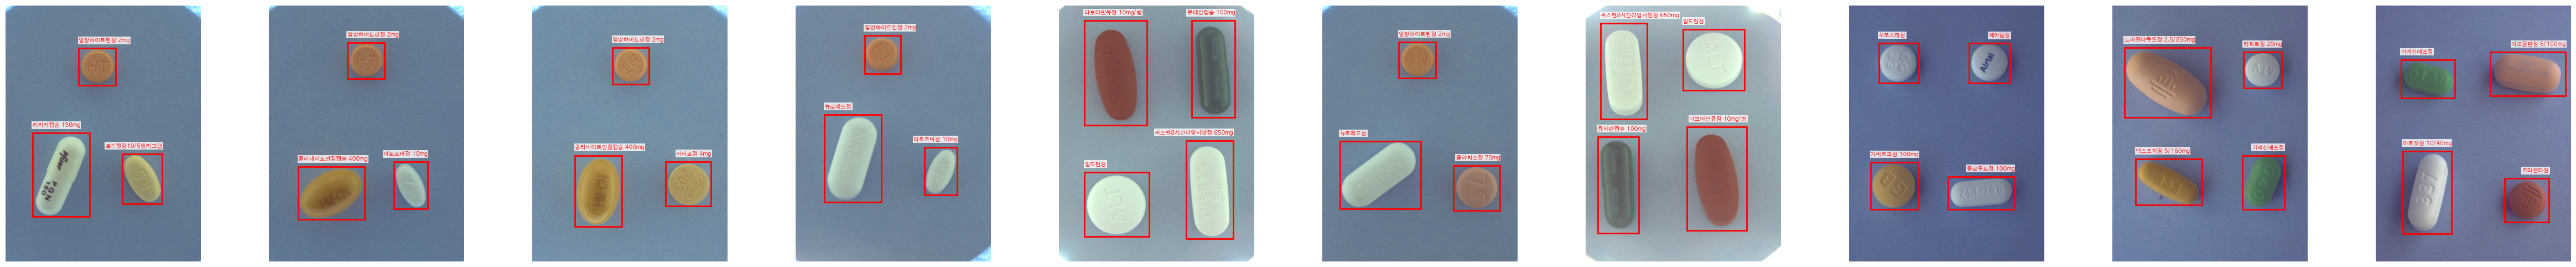

In [77]:
# 샘플 이미지 및 바운딩 박스 시각화
visualize_samples(dataset, num_samples=10)

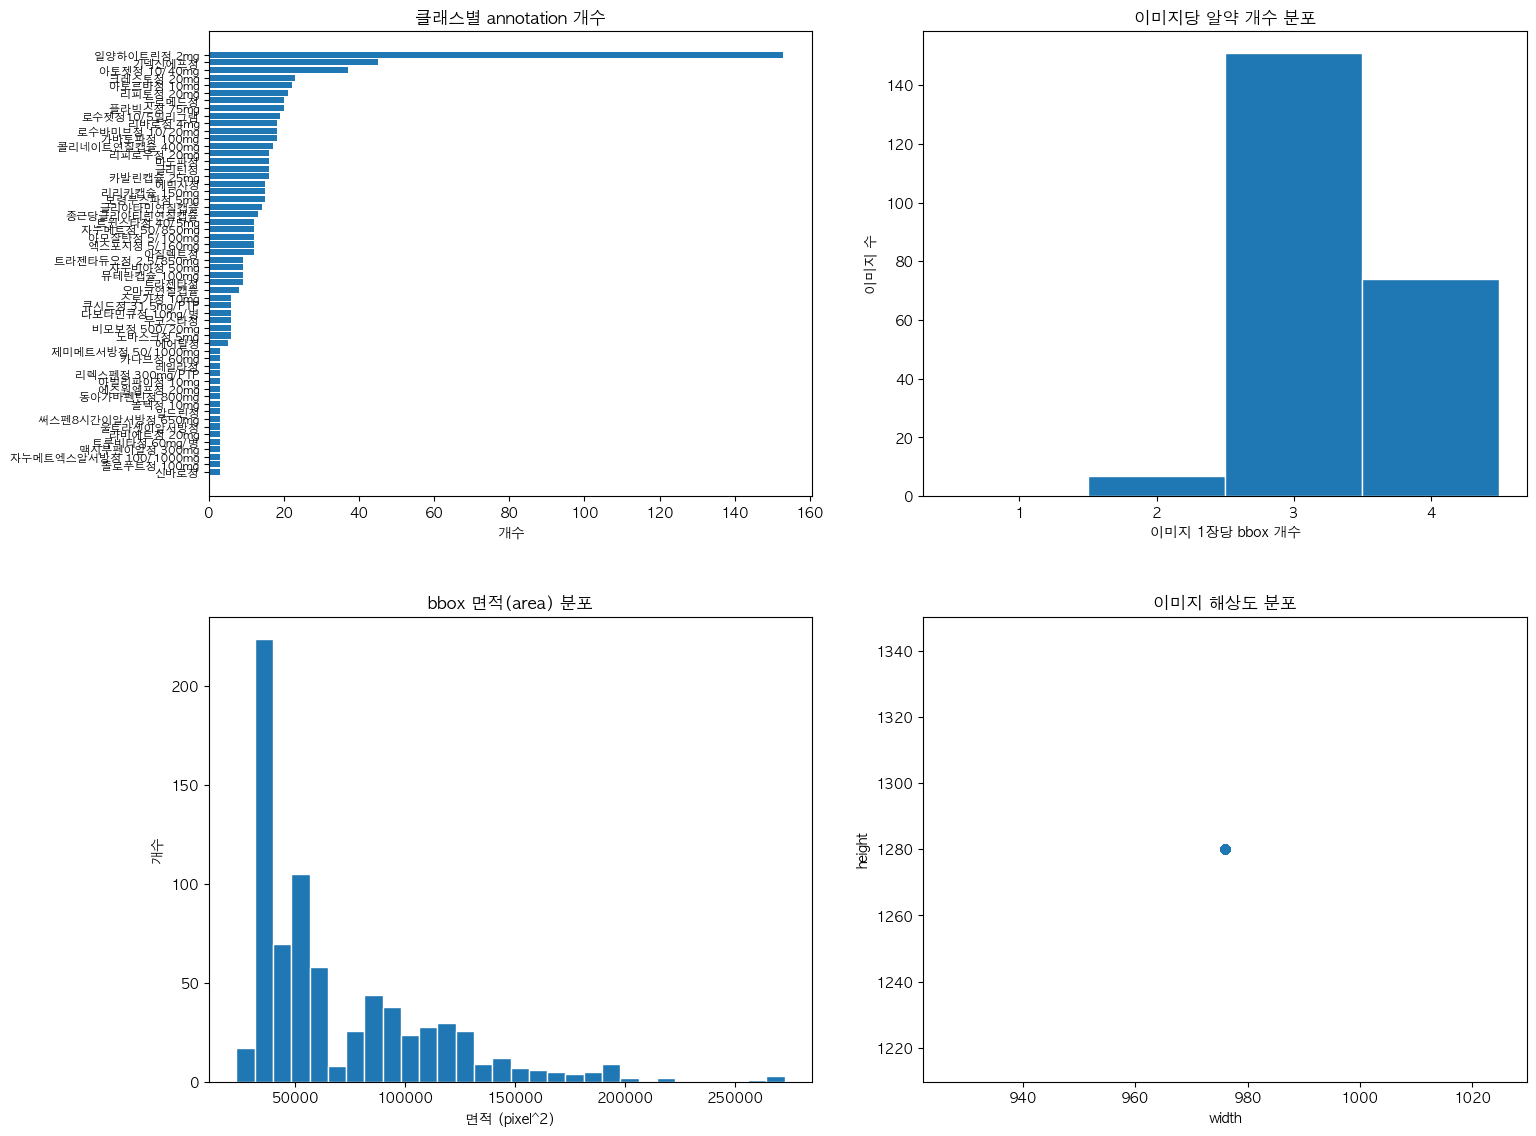

===== EDA 요약 =====
총 이미지 수: 232
총 클래스 수: 56
클래스별 최소/최대 개수: 3 / 153
이미지당 평균 bbox 개수: 3.29
bbox 면적 평균/최소/최대: 70385 / 23250 / 272435
이미지 해상도 종류 수: 1


In [78]:
# 클래스 분포, bbox 통계, 해상도 분포 통계 탐색
run_eda(dataset)

수집된 총 바운딩 박스 개수: 763


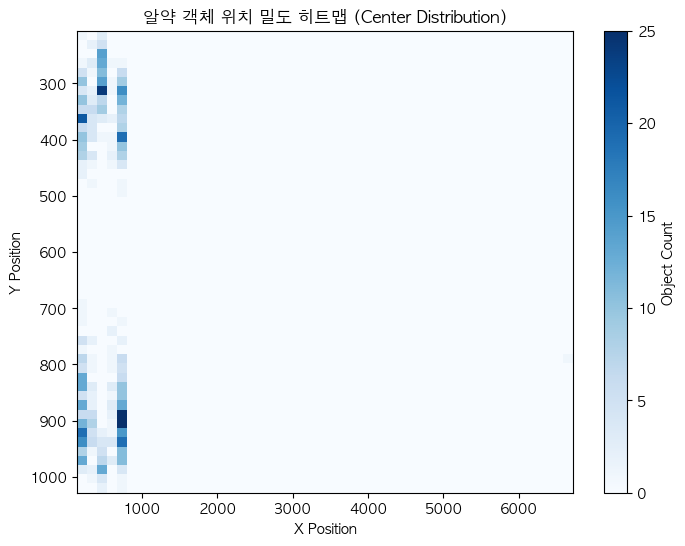

In [79]:
# 객체 위치 밀도 히트맵 탐색
plot_object_heatmap(dataset)